In [8]:
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


##Modelling

from sklearn.metrics import mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [6]:
df = pd.read_csv("stud.csv")

In [7]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
X = df.drop(columns=["math_score"],axis=1)

In [9]:
y = df["math_score"]

In [10]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [11]:
print("Categories in 'gender' variable:", end=" ")
print(df["gender"].unique())

print("Categories in 'race_ethnicity' variable:", end=" ")
print(df["race_ethnicity"].unique())

print("Categories in 'parental_level_of_education' variable:", end=" ")
print(df["parental_level_of_education"].unique())

print("Categories in 'lunch' variable:", end=" ")
print(df["lunch"].unique())

print("Categories in 'test_preparation_course' variable:", end=" ")
print(df["test_preparation_course"].unique())

Categories in 'gender' variable: ['female' 'male']
Categories in 'race_ethnicity' variable: ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental_level_of_education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable: ['standard' 'free/reduced']
Categories in 'test_preparation_course' variable: ['none' 'completed']


In [12]:
## create column transfomer with 3 types of the transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
 [
  ("OneHotEncoder",oh_transformer,cat_features),
  ("StandardScaler",numeric_transformer,num_features),

 ]
)

In [13]:
X = preprocessor.fit_transform(X)

In [14]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]])

In [15]:
X.shape

(1000, 19)

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((800, 19), (200, 19))

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)   

    return mae, rmse, r2

In [33]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

model_names = list(models.keys())
model_objects = list(models.values())

for i in range(len(model_objects)):
    model = model_objects[i]
    name = model_names[i]

    model.fit(X_train, y_train)

    # make prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(name)                      # ✅ print model name
    model_list.append(name)          # ✅ append model name

    print("Model performance for Training set")
    print(f"- RMSE: {model_train_rmse:.4f}")
    print(f"- MAE: {model_train_mae:.4f}")
    print(f"- R2 score: {model_train_r2:.4f}")

    print("----------------------------------")

    print("Model performance for Test set")
    print(f"- RMSE: {model_test_rmse:.4f}")
    print(f"- MAE: {model_test_mae:.4f}")
    print(f"- R2 score: {model_test_r2:.4f}")

    r2_list.append(model_test_r2)

    print("="*35)
    print()

Linear Regression
Model performance for Training set
- RMSE: 5.3231
- MAE: 4.2667
- R2 score: 0.8743
----------------------------------
Model performance for Test set
- RMSE: 5.3940
- MAE: 4.2148
- R2 score: 0.8804

Lasso
Model performance for Training set
- RMSE: 6.5938
- MAE: 5.2063
- R2 score: 0.8071
----------------------------------
Model performance for Test set
- RMSE: 6.5197
- MAE: 5.1579
- R2 score: 0.8253

Ridge
Model performance for Training set
- RMSE: 5.3233
- MAE: 4.2650
- R2 score: 0.8743
----------------------------------
Model performance for Test set
- RMSE: 5.3904
- MAE: 4.2111
- R2 score: 0.8806

K-Neighbors Regressor
Model performance for Training set
- RMSE: 5.7088
- MAE: 4.5177
- R2 score: 0.8554
----------------------------------
Model performance for Test set
- RMSE: 7.2494
- MAE: 5.6090
- R2 score: 0.7840

Decision Tree
Model performance for Training set
- RMSE: 0.2795
- MAE: 0.0187
- R2 score: 0.9997
----------------------------------
Model performance for Te

In [34]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=["Model Name","R2_score"]).sort_values(by=["R2_score"],ascending=False)

,Model Name,R2_score
2,Ridge,0.880593
0,Linear Regression,0.880433
7,CatBoosting Regressor,0.851632
5,Random Forest Regressor,0.850714
8,AdaBoost Regressor,0.848505
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.784030
4,Decision Tree,0.749259


In [35]:
##linear regression
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test,y_pred)*100
print("Accuracy of the model is %.2f" %score)

Accuracy of the model is 88.04


Text(0, 0.5, 'Predicted')

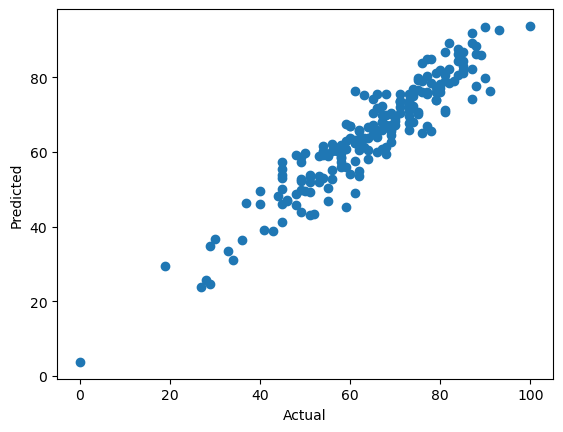

In [36]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='math_score'>

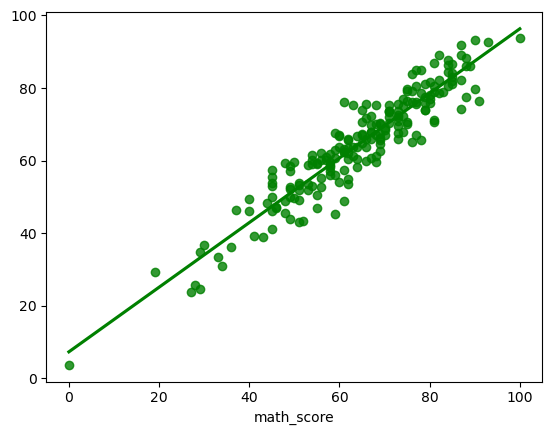

In [38]:
sns.regplot(x=y_test,y=y_pred,ci=None,color="green")

In [42]:
## difference between actual and predicted
pred_df = pd.DataFrame({"Actual value":y_test,"predicted value":y_pred,"Difference":y_test - y_pred})
pred_df

,Actual value,predicted value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
